# House Price Prediction

# Internship Project Week 1

# Name: Noor Afshan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Data Loading and Exploration

In this section, the housing dataset is loaded and explored to understand its structure, columns, and overall quality.

In [2]:
df = pd.read_csv("Housing.csv")

# Displaying the First 10 Rows

The first 10 rows of the dataset are displayed to understand the available features and target variable.

In [3]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


# Dataset Dimensions

The shape of the dataset is checked to determine the number of rows and columns.

In [4]:
df.shape

(545, 13)

# Column Names

The dataset columns are displayed to identify the target variable and input features.

In [5]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

# Dataset Information

The information function provides details about data types, non-null values, and overall dataset structure.

In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

# Checking Missing Values

Missing values can negatively affect model performance. Therefore, each column is checked for null values.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


# Checking Duplicate Records

Duplicate rows may introduce bias in the model. Therefore, duplicate records are identified.

In [8]:
df.duplicated().sum()

np.int64(0)

# Task 2: Data Cleaning and Preprocessing

The dataset is cleaned and categorical features are converted into machine-learning-friendly numerical values.

In [9]:
df_clean = df.copy()

### Encoding Binary Categorical Features

Columns containing "yes" and "no" values are converted into binary numerical values where:

- yes = 1
- no = 0

This allows machine learning algorithms to process these features.

In [11]:
yn_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in yn_cols:
    df_clean[col] = df_clean[col].replace({
        'yes': 1,
        'no': 0
    })

In [98]:
yn_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in yn_cols: 
    df_clean[col] = df_clean[col].replace({
        'yes': 1,
        'no': 0
})

### Verifying Encoded Columns

The transformed columns are checked to ensure successful encoding.

In [12]:
df_clean[['mainroad','guestroom','basement']].head()

,mainroad,guestroom,basement
0,1,0,0
1,1,0,0
2,1,0,1
3,1,0,1
4,1,1,1


### One-Hot Encoding

The furnishing status feature contains multiple categories. One-hot encoding is applied to convert these categories into numerical columns suitable for machine learning.

In [13]:
df_clean = pd.get_dummies(
    df_clean,
    columns = ['furnishingstatus'],
    drop_first = True
)

### Verifying New Features

The updated column names are displayed after one-hot encoding.

In [14]:
df_clean.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi-furnished',
       'furnishingstatus_unfurnished'],
      dtype='object')

# Task 3: Model Building

In this section, machine learning models are developed to predict house prices. The dataset is divided into features (X) and target (y), followed by splitting the data into training and testing sets.

In [15]:
x = df_clean.drop('price', axis=1)
y = df_clean['price']

In [16]:
print(x.shape)
print(y.shape)

(545, 13)
(545,)


# Splitting the Dataset

The dataset is divided into training and testing sets. The training set is used to teach the model, while the testing set is used to evaluate its performance on unseen data.

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)

In [19]:
print(x_train.shape)
print(x_test.shape)

(436, 13)
(109, 13)


# Building a Linear Regression Model

Linear Regression is a basic machine learning algorithm that predicts a continuous value by finding relationships between input features and the target variable.

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_pred_lr = lr_model.predict(x_test)

In [23]:
y_pred_lr[:5]

array([5164653.90033967, 7224722.29802166, 3109863.24240338,
       4612075.3272256 , 3294646.25725955])

# Evaluating the Linear Regression Model

The performance of the Linear Regression model is evaluated using MAE, RMSE, and R² Score.

In [24]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [25]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = mean_squared_error(
    y_test,
    y_pred_lr
) ** 0.5

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

MAE: 970043.4039201634
RMSE: 1324506.9600914384
R2 Score: 0.6529242642153186


### Linear Regression Results

The Linear Regression model achieved an R² Score of approximately 0.65, indicating that it can explain about 65% of the variation in house prices. The model provides a reasonable baseline for house price prediction.

# Building a Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [26]:
from sklearn.ensemble import RandomForestRegressor

In [31]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
y_pred_rf = rf_model.predict(x_test)

In [33]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = mean_squared_error(
    y_test,
    y_pred_rf
) ** 0.5

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 1022560.0527522935
RMSE: 1401496.8425384816
R2 Score: 0.6114024924156645


### Model Comparison

Both Linear Regression and Random Forest Regressor models were trained and evaluated. Linear Regression achieved a higher R² Score and lower error values, making it the better-performing model for this dataset.

In [34]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2 Score": [r2_lr, r2_rf]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.022560e+06,1.401497e+06,0.611402


# Task 4: Visualization

Visualizations help in understanding the distribution of house prices and relationships between different features.

### Chart 1: Distribution of House Prices

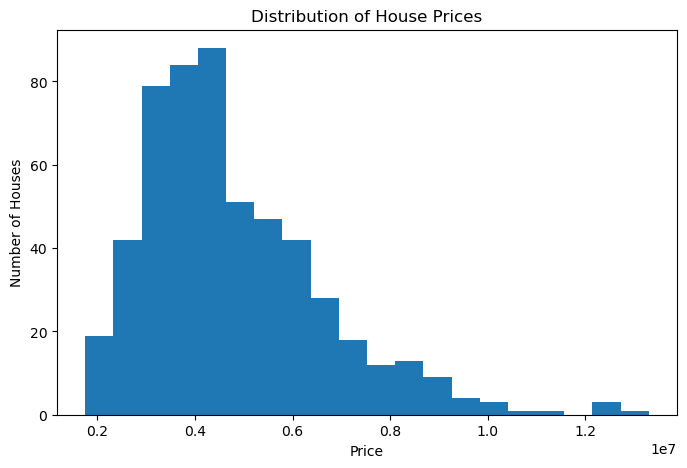

In [35]:
plt.figure(figsize=(8,5))

plt.hist(df['price'], bins=20)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.savefig("chart1_price_distribution.png")
plt.show()

### Chart 2: Correlation Heatmap

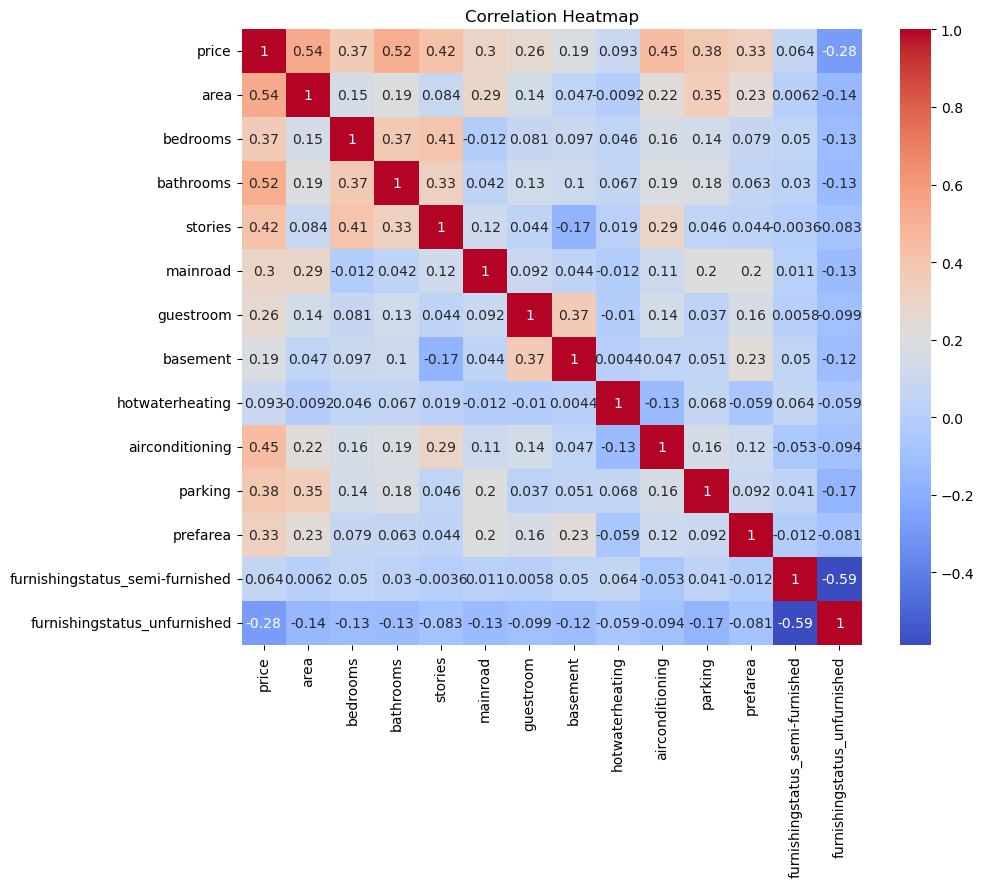

In [36]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_clean.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.savefig("chart2_heatmap.png")
plt.show()

### Chart 3: Relationship Between Area and House Price

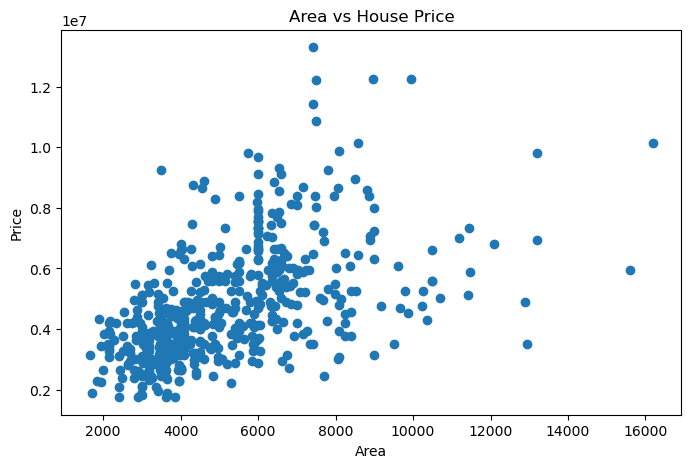

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['area'],
    df['price']
)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs House Price")

plt.savefig("chart3_area_vs_price.png")
plt.show()

### Model Performance Summary

Linear Regression achieved:

- MAE: 970043
- RMSE: 1324507
- R² Score: 0.65

Random Forest achieved:

- MAE: 1022560
- RMSE: 1401497
- R² Score: 0.61

Linear Regression performed better and was selected as the final model.

# Task 5: Insights and Summary

The analysis found that area, bathrooms, air conditioning, and number of stories are important factors affecting house prices. Among all features, area and bathrooms showed the strongest positive correlation with price.

The Linear Regression model performed better than the Random Forest model. It achieved an R² Score of 0.65, meaning it could explain about 65% of the variation in house prices. The model also produced lower error values, making it the best model for this dataset.

One interesting observation was that a simple Linear Regression model outperformed the more complex Random Forest model. This was unexpected because Random Forest is usually considered a more advanced algorithm.

The charts showed that larger houses generally have higher prices. The positive relationship between area and price was clearly visible in the scatter plot.

Based on the results, real estate companies should pay special attention to property size, number of bathrooms, and important amenities while estimating house prices.